In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import joblib
from wrf_io import postproc
from scipy.io import loadmat
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import mean_squared_error

In [2]:
base_path = '/home1/09909/smata/dir_scratch/induction_modeling/gaussian_process/10MW'

In [3]:
orig_kernel, opt_kernel_rot = postproc.build_kernel_from_search(base_path + '/results/rotor/wrf_10MW_rot_D3_result.txt')

Kernel line:
ScoredKernel(k_opt=SumKernel([ MaskKernel(ndim=3, active_dimension=1, base_kernel=SqExpKernel(lengthscale=-0.366678, output_variance=1.364362)), ProductKernel([ MaskKernel(ndim=3, active_dimension=0, base_kernel=SqExpKernel(lengthscale=2.555432, output_variance=4.381824)), MaskKernel(ndim=3, active_dimension=2, base_kernel=SqExpKernel(lengthscale=2.341696, output_variance=-2.022604)) ]) ]), nll=-107.193919, laplace_nle=nan, bic_nle=-193.672165, noise=[-4.23481442])

Noise:
-4.23481442

Kernel specification string:
SumKernel([ MaskKernel(ndim=3, active_dimension=1, base_kernel=SqExpKernel(lengthscale=-0.366678, output_variance=1.364362)), ProductKernel([ MaskKernel(ndim=3, active_dimension=0, base_kernel=SqExpKernel(lengthscale=2.555432, output_variance=4.381824)), MaskKernel(ndim=3, active_dimension=2, base_kernel=SqExpKernel(lengthscale=2.341696, output_variance=-2.022604)) ]) ])

Kernel structure:
{'children': [{'active_dimension': 1,
               'base_kernel': {'leng

In [5]:
postproc.compare_kernel_dict_and_sklearn(orig_kernel, opt_kernel_rot, tol=0.1, verbose=True)

root: Not a MaskedKernel, got MaskedKernel(1.18**2 * RBF(length_scale=1.25), active_dims=[1]) + WhiteKernel(noise_level=0.709)


False

In [4]:
# Load training data
X_train_rot = loadmat(base_path + '/train_data/wrf_10MW_rot.mat')

X_rot = X_train_rot['X']
y_rot = X_train_rot['y'].ravel()

In [5]:
# Train the GP model
gpr = GaussianProcessRegressor(kernel=opt_kernel_rot, optimizer=None, normalize_y=False)
# gpr = GaussianProcessRegressor(kernel=opt_kernel_rot, optimizer='fmin', normalize_y=False)
gpr.fit(X_rot, y_rot)

joblib.dump(gpr, '/home1/09909/smata/dir_scratch/induction_modeling/gaussian_process/10MW/results/rotor/wrf_10MW_rot_GPR.pkl')


['/home1/09909/smata/dir_scratch/induction_modeling/gaussian_process/10MW/results/rotor/wrf_10MW_rot_GPR.pkl']

In [21]:
gpr.predict(np.column_stack([-0.6844641, 0.0, -0.2300895]), return_std=True)

(array([0.64825717]), array([0.12733349]))

In [22]:
obj_ann.inverse_transform(np.array([0.64825717]).reshape(-1, 1)).ravel()

array([0.25036])

In [ ]:
CT:[-5.48839802]
sheer:[0.]
veer:[-0.2300895]

In [13]:
# Load test data
X_test_rot = loadmat(base_path + '/test_data/wrf_10MW_rot.mat')
import pickle

# X_t_rot = np.zeros((250,3))

# Replace with the actual file path
with open(base_path + '/train_data/scaler_wrf_cot_rot.pkl', 'rb') as f:
    obj_cot1 = pickle.load(f)

with open(base_path + '/train_data/scaler_shears_rot.pkl', 'rb') as f:
    obj_cot2 = pickle.load(f)

with open(base_path + '/train_data/scaler_veers_rot.pkl', 'rb') as f:
    obj_cot3 = pickle.load(f)

with open(base_path + '/train_data/scaler_wrf_ind_rot.pkl', 'rb') as f:
    obj_ann = pickle.load(f)

X_t_rot = np.zeros((90,3))
# X_t_rot[:,0] = obj_cot1.inverse_transform(X_test_rot['X'][:,0].reshape(-1, 1)).ravel()
# X_t_rot[:,1] = obj_cot2.inverse_transform(X_test_rot['X'][:,1].reshape(-1, 1)).ravel()
# X_t_rot[:,2] = obj_cot3.inverse_transform(X_test_rot['X'][:,2].reshape(-1, 1)).ravel()
# y_t_rot = obj_ann.inverse_transform(X_test_rot['y'])
X_t_rot = X_test_rot['X']
y_t_rot = X_test_rot['y']

In [8]:
X_t_rot[:,0] = obj_cot1.transform(np.linspace(0.66,0.72,250).reshape(-1, 1)).ravel()
X_t_rot[:,1] = obj_cot2.transform(0.03*np.ones(250).reshape(-1, 1)).ravel()
X_t_rot[:,2] = obj_cot3.transform(0.2*np.ones(250).reshape(-1, 1)).ravel()
X_t_rot

array([[-3.97330828,  1.5       ,  1.84071597],
       [-3.93820588,  1.5       ,  1.84071597],
       [-3.90310349,  1.5       ,  1.84071597],
       [-3.86800109,  1.5       ,  1.84071597],
       [-3.83289869,  1.5       ,  1.84071597],
       [-3.79779629,  1.5       ,  1.84071597],
       [-3.76269389,  1.5       ,  1.84071597],
       [-3.7275915 ,  1.5       ,  1.84071597],
       [-3.6924891 ,  1.5       ,  1.84071597],
       [-3.6573867 ,  1.5       ,  1.84071597],
       [-3.6222843 ,  1.5       ,  1.84071597],
       [-3.5871819 ,  1.5       ,  1.84071597],
       [-3.55207951,  1.5       ,  1.84071597],
       [-3.51697711,  1.5       ,  1.84071597],
       [-3.48187471,  1.5       ,  1.84071597],
       [-3.44677231,  1.5       ,  1.84071597],
       [-3.41166991,  1.5       ,  1.84071597],
       [-3.37656752,  1.5       ,  1.84071597],
       [-3.34146512,  1.5       ,  1.84071597],
       [-3.30636272,  1.5       ,  1.84071597],
       [-3.27126032,  1.5       ,  1.840

In [26]:
X_t_rot

array([[ 0.67991043, -0.035     , -0.25      ],
       [ 0.69121898, -0.035     , -0.15      ],
       [ 0.69807907, -0.035     , -0.075     ],
       [ 0.70054698, -0.035     , -0.035     ],
       [ 0.70168386, -0.035     , -0.01      ],
       [ 0.7025056 , -0.035     ,  0.01      ],
       [ 0.70336482, -0.035     ,  0.035     ],
       [ 0.70384613, -0.035     ,  0.075     ],
       [ 0.70097957, -0.035     ,  0.15      ],
       [ 0.69629282, -0.035     ,  0.25      ],
       [ 0.67626602, -0.025     , -0.25      ],
       [ 0.68646431, -0.025     , -0.15      ],
       [ 0.6927981 , -0.025     , -0.075     ],
       [ 0.69526697, -0.025     , -0.035     ],
       [ 0.69646098, -0.025     , -0.01      ],
       [ 0.69724866, -0.025     ,  0.01      ],
       [ 0.69797169, -0.025     ,  0.035     ],
       [ 0.69847114, -0.025     ,  0.075     ],
       [ 0.69706423, -0.025     ,  0.15      ],
       [ 0.69210335, -0.025     ,  0.25      ],
       [ 0.67255559, -0.015     , -0.25 

In [14]:
out_sample = [i for i, (ct, s, v) in enumerate(X_t_rot) if (abs(v) > 0.2 or abs(s) > 0.03)]

In [15]:
full_range = np.arange(0, len(X_t_rot))  # inclusive of 90
in_sample = np.setdiff1d(full_range, out_sample)

In [16]:
A_pred, sigma = gpr.predict(X_t_rot, return_std=True)

X_t_rot = np.zeros((90,3))
X_t_rot[:,0] = obj_cot1.inverse_transform(X_test_rot['X'][:,0].reshape(-1, 1)).ravel()
X_t_rot[:,1] = obj_cot2.inverse_transform(X_test_rot['X'][:,1].reshape(-1, 1)).ravel()
X_t_rot[:,2] = obj_cot3.inverse_transform(X_test_rot['X'][:,2].reshape(-1, 1)).ravel()
y_t_rot = obj_ann.inverse_transform(X_test_rot['y'])

# X_t_rot = obj_cot.inverse_transform(X_test_rot['X'])
# y_t_rot = obj_ann.inverse_transform(X_test_rot['y'])
A_pred = obj_ann.inverse_transform(A_pred.reshape(-1, 1))

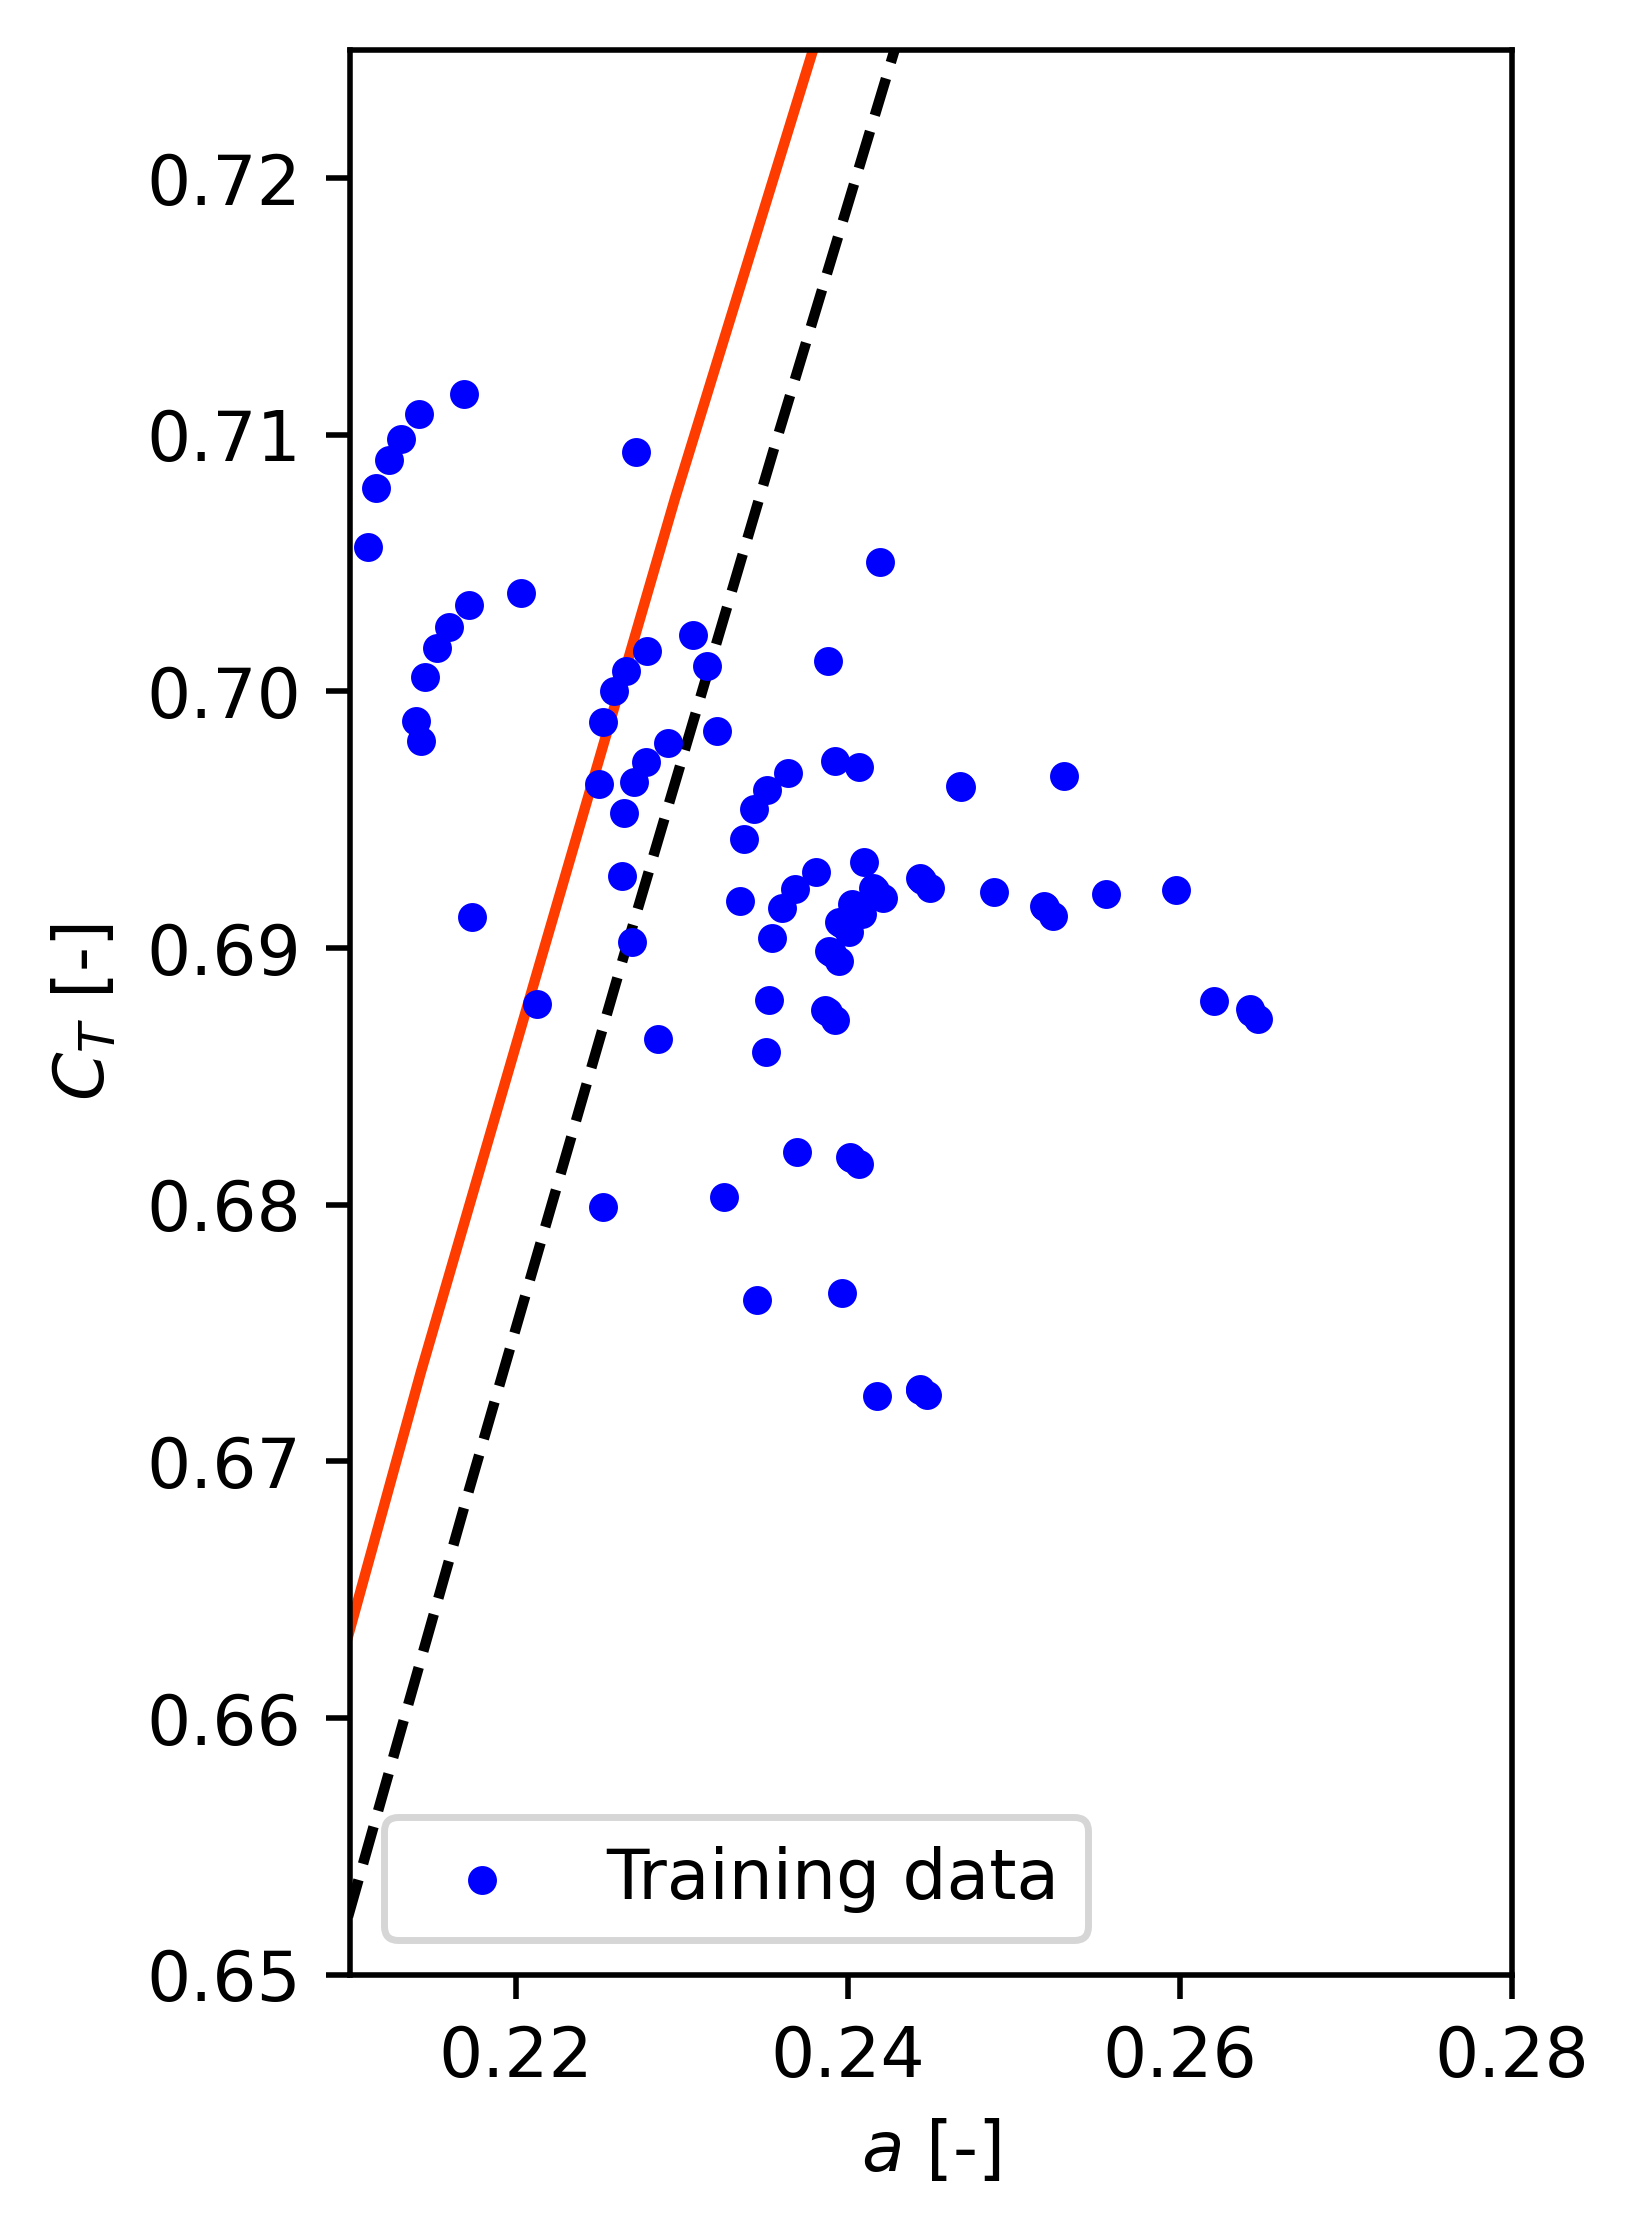

In [20]:

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(3, 5))

ax.plot(a_mom,ct_mom,'#ff3c00',zorder=1)
ax.plot(a_mad,ct_mad,'k--',zorder=1)
ax.scatter(y_t_rot,X_t_rot[:,0],10,color='b',label='Training data')

ax.set_xlim([0.21,0.28])
ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

ax.legend()

In [88]:
X_rot

array([[-1.54970985e+00, -1.50000000e+00, -1.84071597e+00],
       [-1.29378508e-01, -1.50000000e+00, -9.20357987e-01],
       [ 3.87584765e-01, -1.50000000e+00, -4.60178993e-01],
       [ 5.81712812e-01, -1.50000000e+00, -2.30089497e-01],
       [ 1.37326917e+00, -1.50000000e+00,  4.05477233e-18],
       [ 8.67827588e-01, -1.50000000e+00,  2.30089497e-01],
       [ 9.54146739e-01, -1.50000000e+00,  4.60178993e-01],
       [ 9.54123444e-01, -1.50000000e+00,  9.20357987e-01],
       [ 3.56170973e-01, -1.50000000e+00,  1.84071597e+00],
       [-2.07342768e+00, -1.00000000e+00, -1.84071597e+00],
       [-7.61731764e-01, -1.00000000e+00, -9.20357987e-01],
       [-2.67171196e-01, -1.00000000e+00, -4.60178993e-01],
       [-7.31635739e-02, -1.00000000e+00, -2.30089497e-01],
       [ 7.04121535e-01, -1.00000000e+00,  4.05477233e-18],
       [ 1.96711491e-01, -1.00000000e+00,  2.30089497e-01],
       [ 2.68907910e-01, -1.00000000e+00,  4.60178993e-01],
       [ 2.78494691e-01, -1.00000000e+00

In [99]:
# X_rot[:,0] = obj_cot1.inverse_transform(X_rot[:,0].reshape(-1, 1)).ravel()
# X_rot[:,1] = obj_cot2.inverse_transform(X_rot[:,1].reshape(-1, 1)).ravel()
# X_rot[:,2] = obj_cot3.inverse_transform(X_rot[:,2].reshape(-1, 1)).ravel()
# y_rot = obj_ann.inverse_transform(y_rot.reshape(-1, 1)).ravel()

X_rot[:,1]

array([-0.03, -0.03, -0.03, -0.03, -0.03, -0.03, -0.03, -0.03, -0.03,
       -0.02, -0.02, -0.02, -0.02, -0.02, -0.02, -0.02, -0.02, -0.02,
       -0.01, -0.01, -0.01, -0.01, -0.01, -0.01, -0.01, -0.01, -0.01,
        0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
        0.01,  0.01,  0.01,  0.01,  0.01,  0.01,  0.01,  0.01,  0.01,
        0.02,  0.02,  0.02,  0.02,  0.02,  0.02,  0.02,  0.02,  0.02,
        0.03,  0.03,  0.03,  0.03,  0.03,  0.03,  0.03,  0.03,  0.03])

In [106]:
shear_to_color.get(np.round(X_rot[0, 1], 2), 'gray')

array([0.267004, 0.004874, 0.329415, 1.      ])

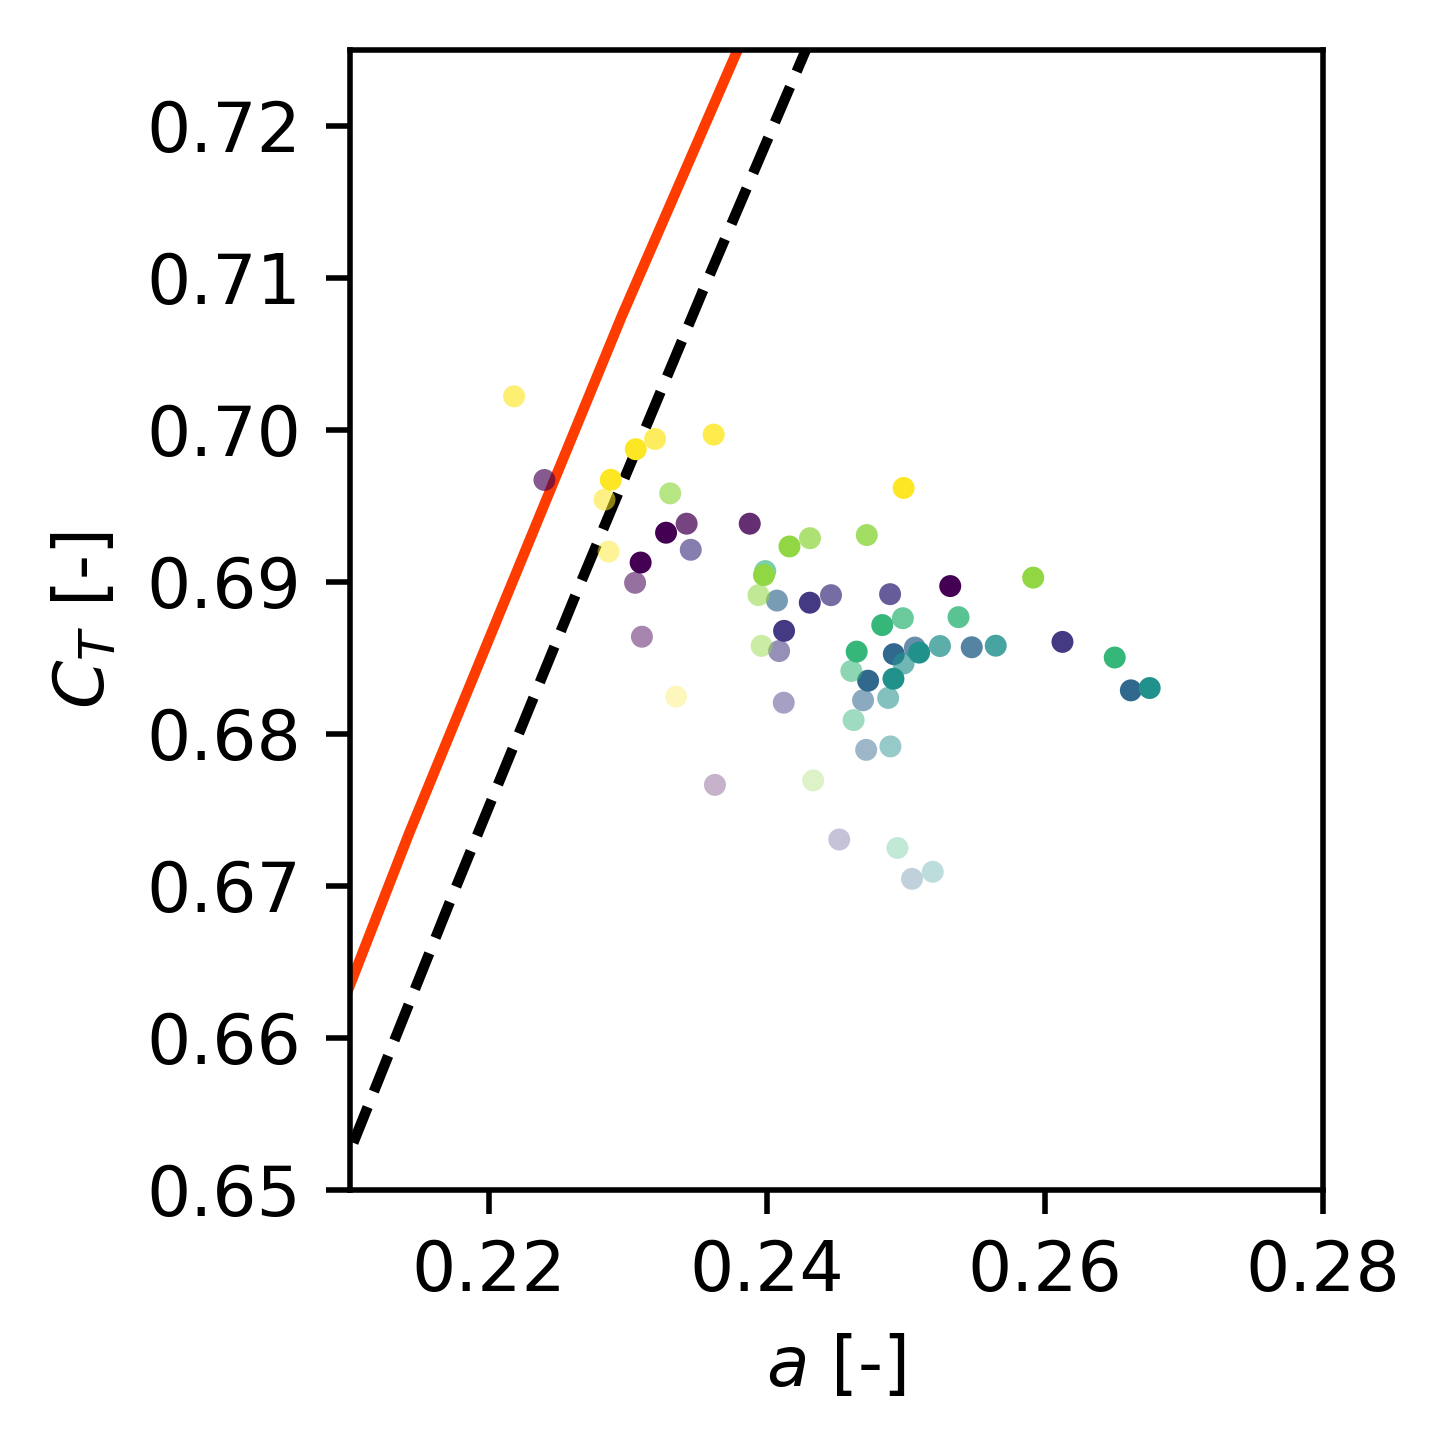

In [116]:
import matplotlib.pyplot as plt
from itertools import product
import numpy as np

X_rot[:,0] = obj_cot1.inverse_transform(X_rot[:,0].reshape(-1, 1)).ravel()
X_rot[:,1] = obj_cot2.inverse_transform(X_rot[:,1].reshape(-1, 1)).ravel()
X_rot[:,2] = obj_cot3.inverse_transform(X_rot[:,2].reshape(-1, 1)).ravel()
y_rot = obj_ann.inverse_transform(y_rot.reshape(-1, 1)).ravel()

X_rot[:,1] = np.round(X_rot[:,1], 2)
X_rot[:,2] = np.round(X_rot[:,2], 2)

# Models
a_mom = np.linspace(0, 0.75, 50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0, 1.5, 75)
k1, k2, k3 = 0.2460, 0.0586, 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

# Define shear and veer values used in training
shear_train = [-0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03]
veer_train = [-0.2, -0.1, -0.05, -0.025, 0, 0.025, 0.05, 0.1, 0.2]

# Assign color per shear
color_map = plt.cm.viridis(np.linspace(0, 1, len(shear_train)))
shear_to_color = {s: c for s, c in zip(shear_train, color_map)}

# Assign alpha per veer (fixed values to match earlier mapping)
def compute_alpha(veer):
    return 0.3 + 0.7 * (veer - min(veer_train)) / (max(veer_train) - min(veer_train))
veer_to_alpha = {v: compute_alpha(v) for v in veer_train}

# Create the plot
fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(a_mom, ct_mom, '#ff3c00', zorder=1)
ax.plot(a_mad, ct_mad, 'k--', zorder=1)

# Scatter training points with matching color and alpha
for i in range(len(X_rot)):
    shear = X_rot[i, 1]
    veer = X_rot[i, 2]
    
    color = shear_to_color.get(shear, 'gray')   # fallback in case it's not in dict
    alpha = veer_to_alpha.get(veer, 1.0)        # fallback to fully opaque
    
    ax.scatter(y_rot[i], X_rot[i, 0], s=10, color=color, alpha=alpha, zorder=2, edgecolor='none')

ax.set_xlim([0.21, 0.28])
ax.set_ylim([0.65, 0.725])
ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')
# ax.legend()

plt.tight_layout()
plt.show()


In [98]:
shear_to_color.get(0.03, 'gray')

array([0.993248, 0.906157, 0.143936, 1.      ])

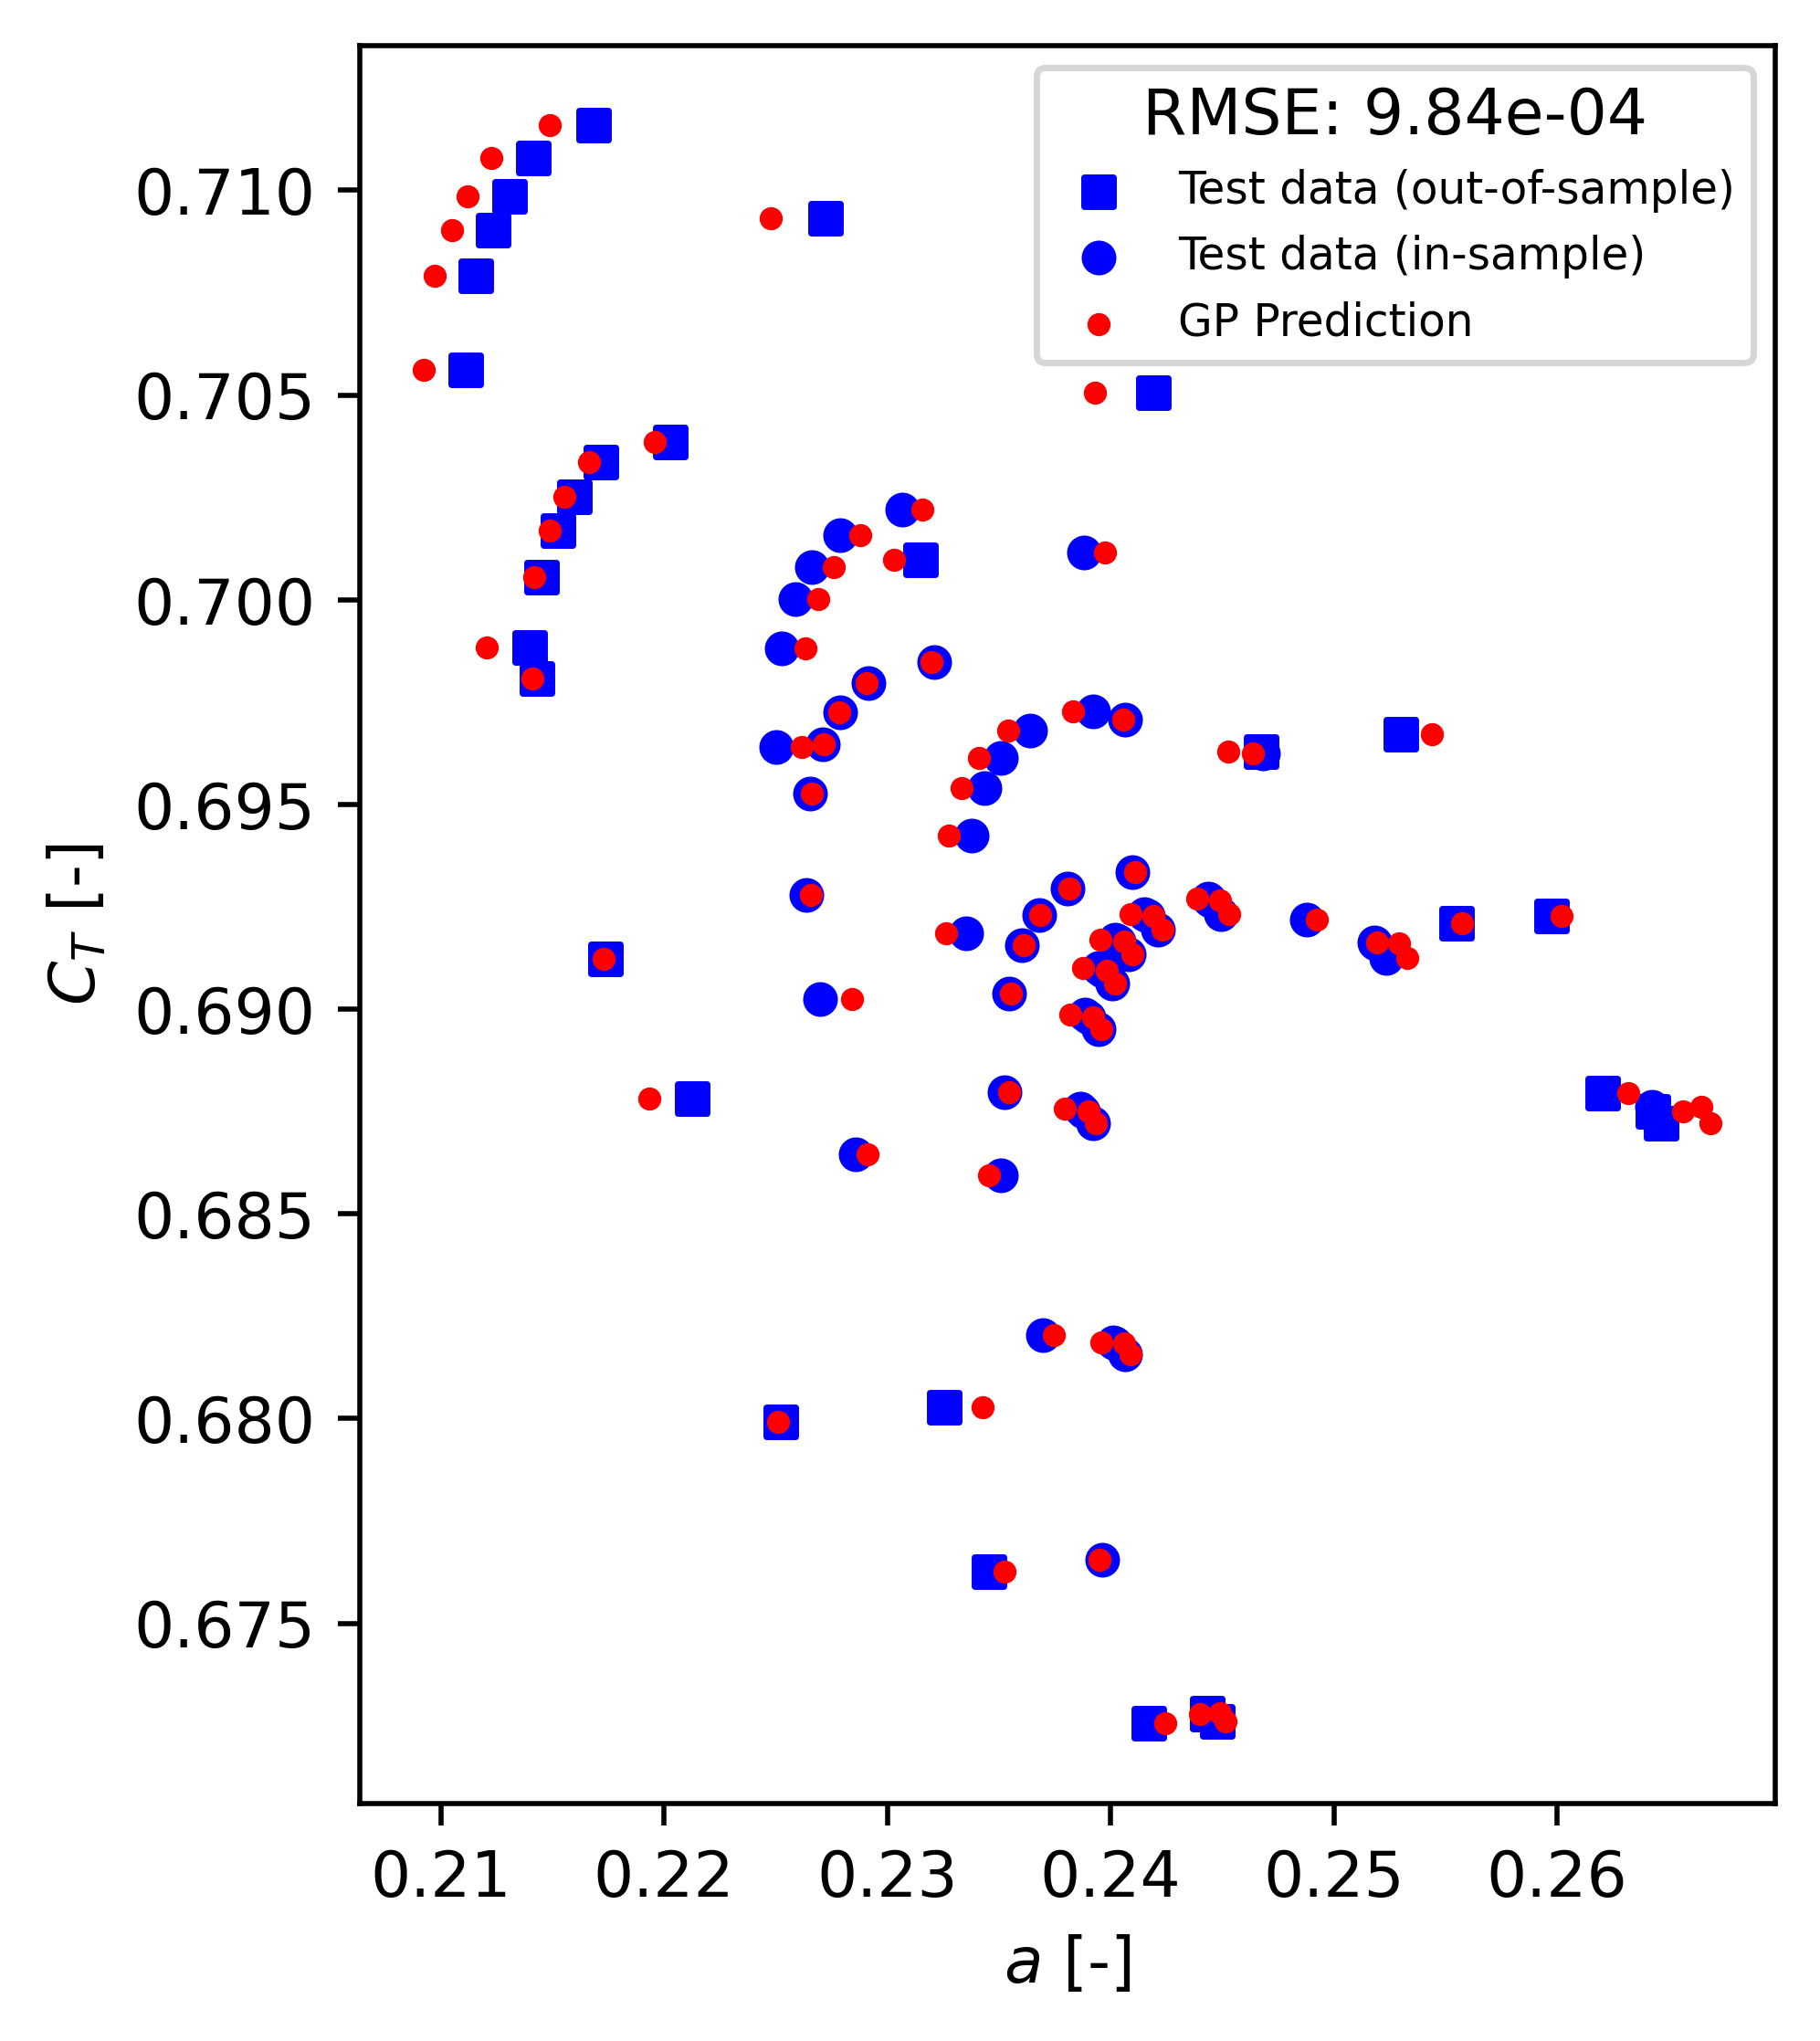

In [17]:
out_sample = np.array([0,1,2,3,4,5,6,7,8,9,10,19,20,29,30,39,40,49,50,69,70,79,80,81,82,83,84,85,86,87,88,89])
full_range = np.arange(0, 90)  # inclusive of 90
in_sample = np.setdiff1d(full_range, out_sample)

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(4, 5))

# ax.plot(a_mom,ct_mom,'#ff3c00',zorder=1)
# ax.plot(a_mad,ct_mad,'k--',zorder=1)
# ax.scatter(y_train,X_train[:,0],color='b')

# ax.scatter(y_t_rot, X_t_rot[:, 0], s=20, color='b', marker='s', label='Test data (out-of-sample)')

ax.scatter(y_t_rot[out_sample], X_t_rot[out_sample, 0], s=20, color='b', marker='s', label='Test data (out-of-sample)')
ax.scatter(y_t_rot[in_sample], X_t_rot[in_sample, 0], s=20, color='b', marker='o', label='Test data (in-sample)')

# ax.scatter(A_pred,np.linspace(0.66,0.72,250),7,color='r', label = 'GP Prediction')
ax.scatter(A_pred,X_t_rot[:,0],7,color='r', label = 'GP Prediction')


# ax.set_xlim([0.21,0.28])
# ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

rmse = np.sqrt(mean_squared_error(y_t_rot, A_pred))
ax.legend(fontsize=7, title=f"RMSE: {rmse:.2e}")

In [55]:
rmse

np.float64(0.0019010898616004647)

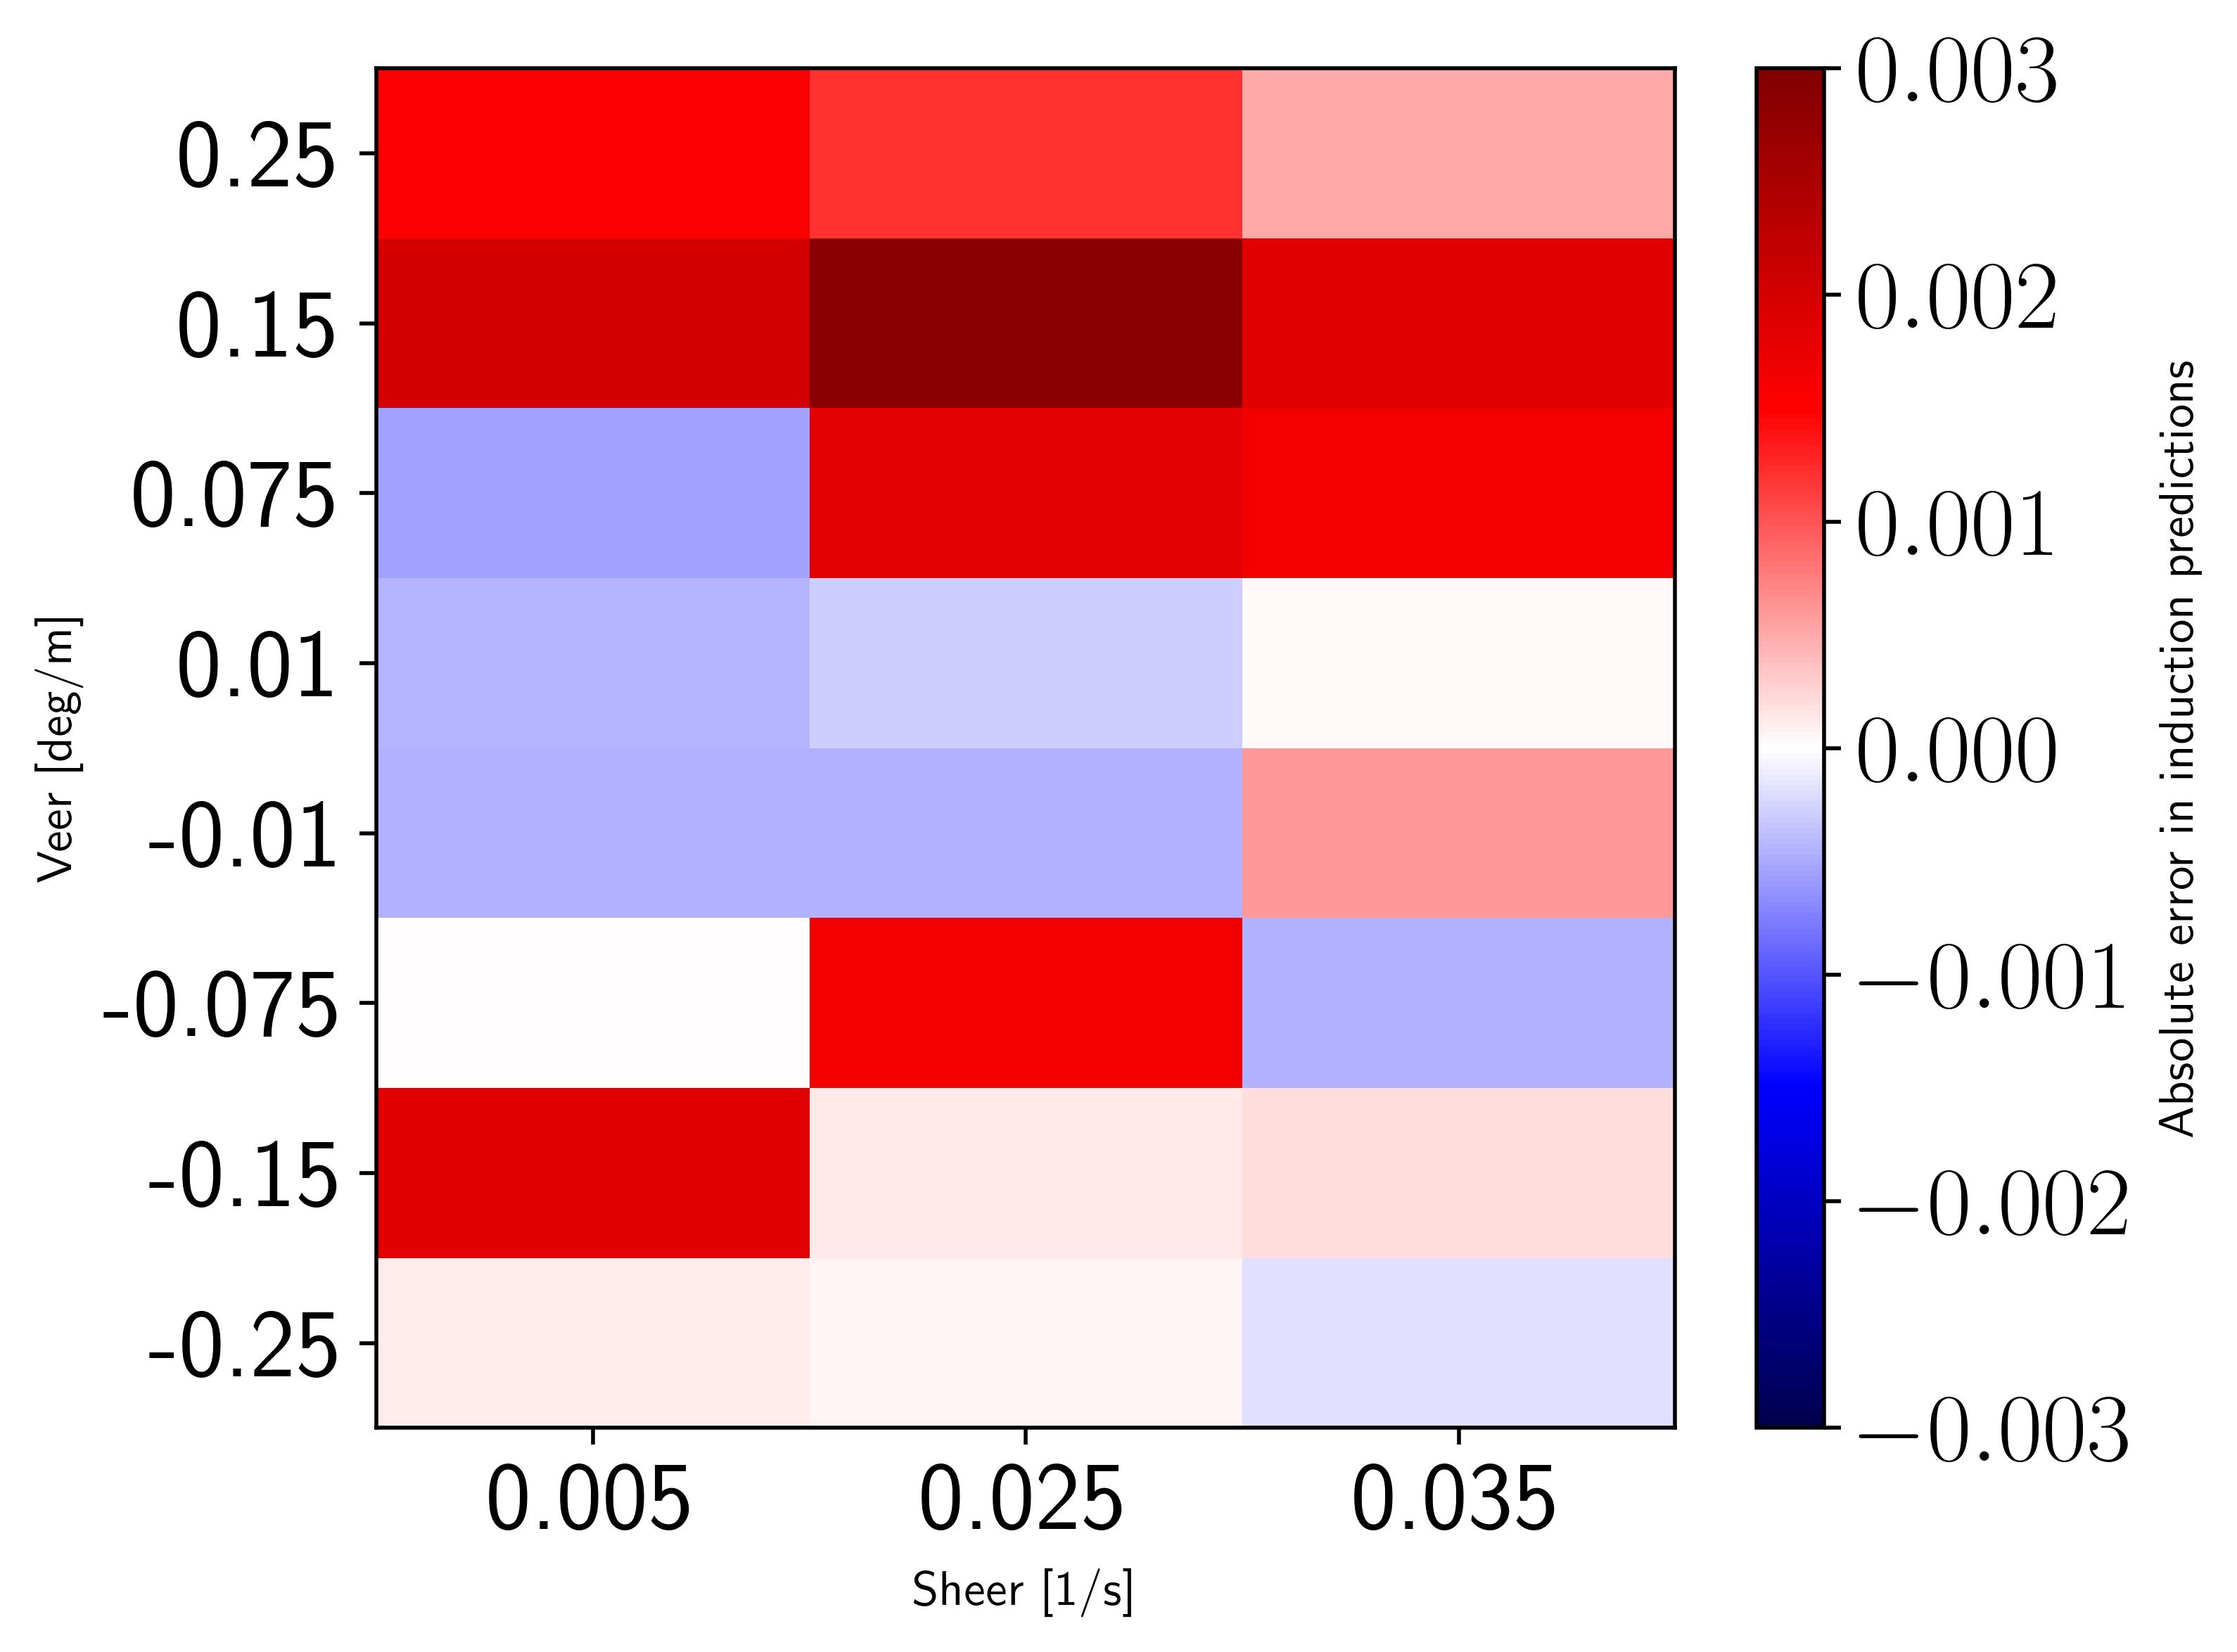

In [182]:
import numpy as np
import matplotlib.pyplot as plt

# Example 2D data
data = (y_test - A_pred).reshape(8,3)
# data = A_pred.reshape(8,3)


# Define the edges of the grid (must be one more than data.shape)
x_edges = np.arange(data.shape[1] + 1)  # 4 edges for 3 columns
y_edges = np.arange(data.shape[0] + 1)  # 5 edges for 4 rows

r's035_v010',
r's035_v075',
r's035_v150',
r's035_v250',
r's035_vn010',
r's035_vn075',
r's035_vn150',
r's035_vn250',

# Define tick labels you want to appear at cell centers
x_tick_labels = ['0.005', '0.025', '0.035']
y_tick_labels = ['-0.25','-0.15','-0.075','-0.01','0.01','0.075','0.15','0.25']

# Compute centers of the grid cells (midpoints between edges)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

# Set custom tick locations (centers of cells)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

# Plot
fig, ax = plt.subplots()
mesh = ax.pcolormesh(x_edges, y_edges, data, shading='auto', cmap='seismic',vmin=-0.003,vmax=0.003)

# Set ticks at cell centers
ax.set_xticks(x_centers)
ax.set_xticklabels(x_tick_labels)

ax.set_yticks(y_centers)
ax.set_yticklabels(y_tick_labels)

# Optional: add a colorbar
plt.colorbar(mesh, ax=ax, label='Absolute error in induction predictions')
plt.ylabel('Veer [deg/m]')
plt.xlabel('Sheer [1/s]')
plt.tight_layout()
plt.show()

In [43]:
np.sqrt(mean_squared_error(y_t_rot[in_sample], A_pred[in_sample]))

np.float64(0.0021064180195931566)

In [44]:
np.sqrt(mean_squared_error(y_t_rot[out_sample], A_pred[out_sample]))

np.float64(0.0015029482268319502)

In [45]:
D1_ormse = 0.013945713870116757
D2_ormse = 0.010466798453807378
D3_ormse = 0.0013883434470080532
D4_ormse = 0.0012974917765304352
D5_ormse = 0.0015029482268319502

ormses = [D1_ormse, D2_ormse, D3_ormse, D4_ormse, D5_ormse]

In [46]:
D1_irmse = 0.010447406416255347
D2_irmse = 0.008690095334648798
D3_irmse = 0.0006208289445140079
D4_irmse = 0.0017682189945665853
D5_irmse = 0.0021064180195931566

irmses = [D1_irmse, D2_irmse, D3_irmse, D4_irmse, D5_irmse]

depth = [1,2,3,4,5]

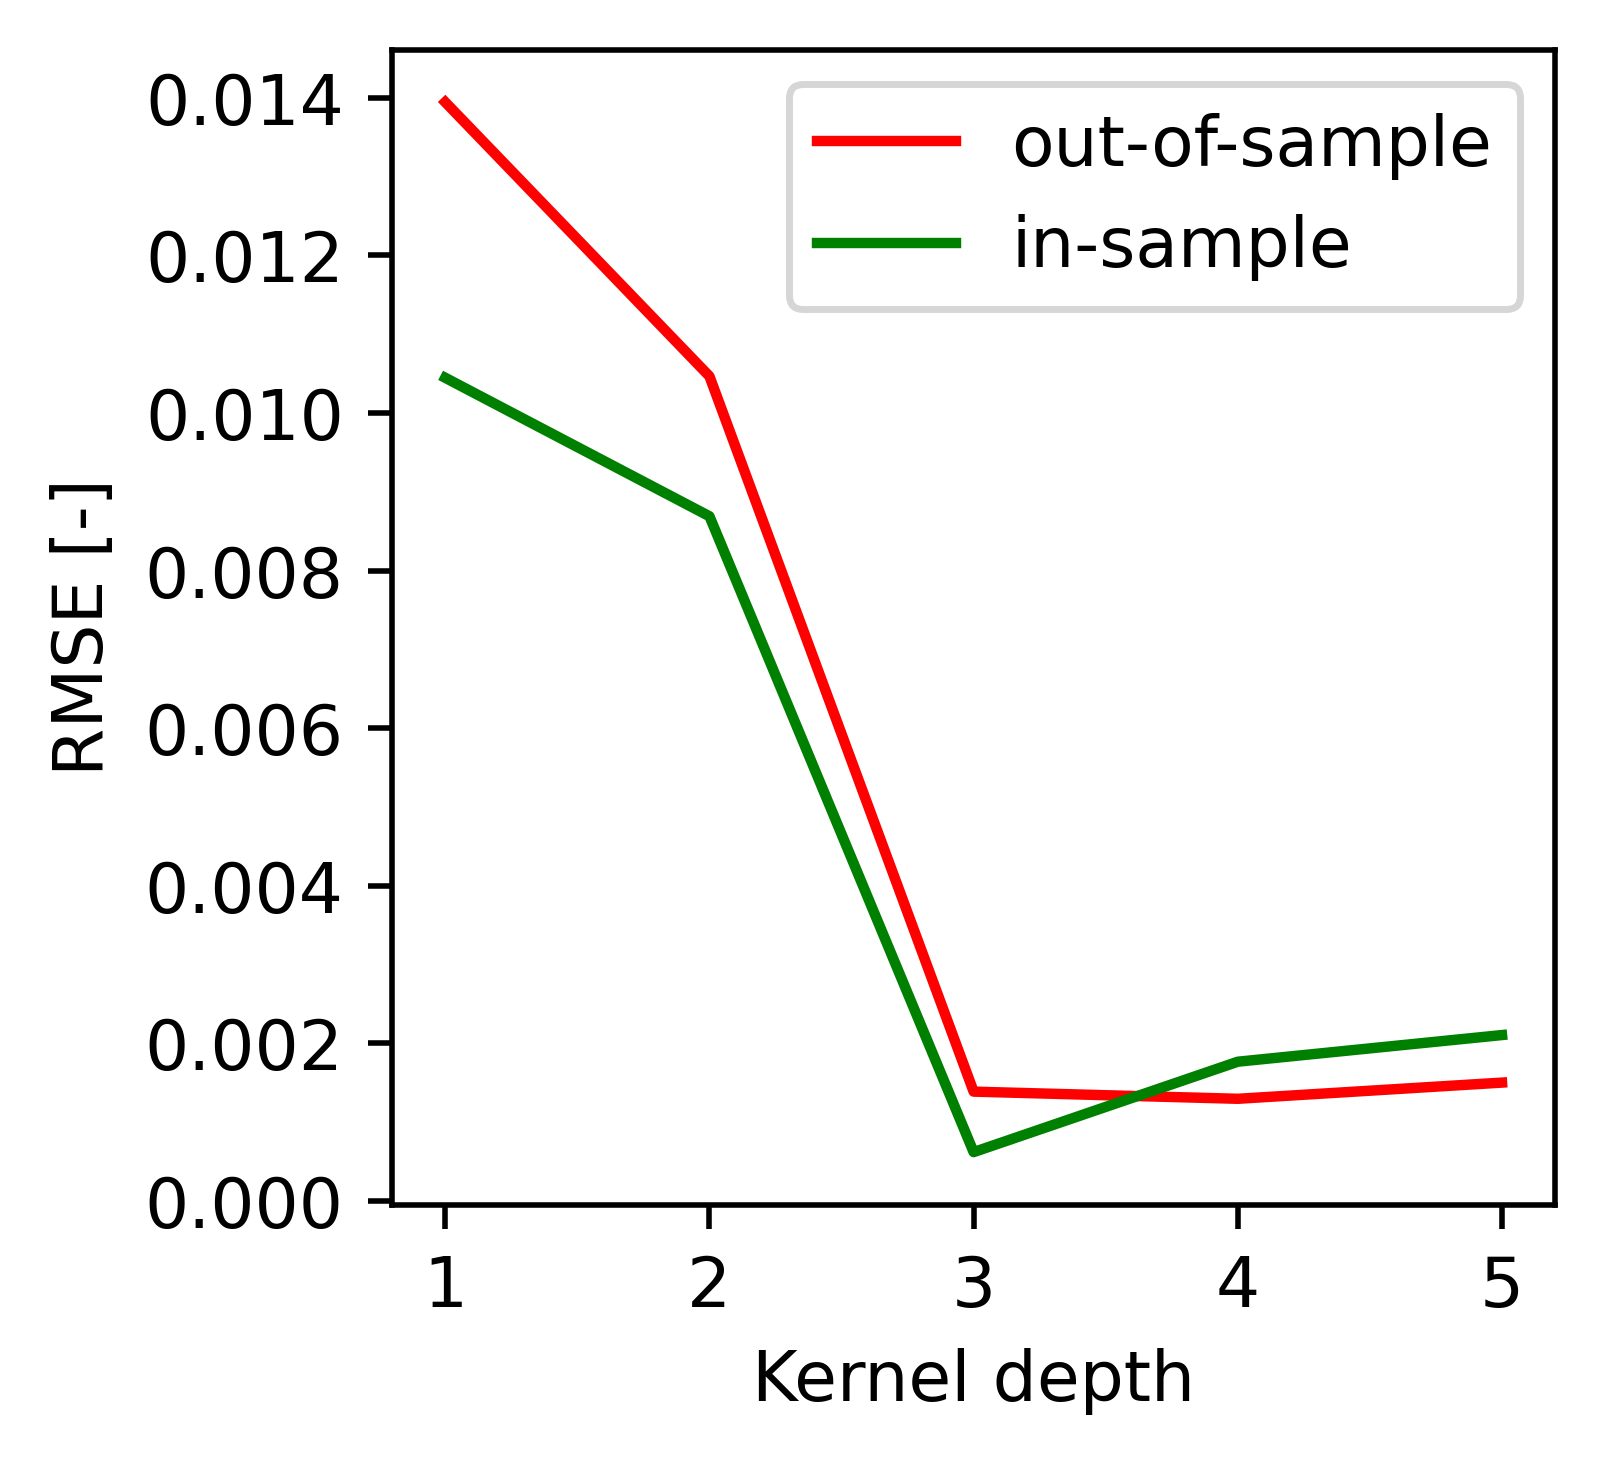

In [47]:
fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(depth,ormses, color='r', label='out-of-sample')
ax.plot(depth,irmses, color='g', label='in-sample')
ax.set_ylabel('RMSE [-]')
ax.set_xlabel('Kernel depth')
ax.legend()